In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import datetime as dt
import joblib

import sklearn
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

In [2]:
df = pd.read_csv('/content/drive/MyDrive/Dataset/preprocessed_retail_data.csv')
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


In [3]:
df.shape

(321007, 9)

In [5]:
# konversi tipe data InvoiceDate menjadi datetime
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# Membuat snapshot dengan acuan H+1 transaksi terakhir
snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

# Hitung RFM
rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,  # Recency
    'InvoiceNo': 'nunique',                                   # Frequency
    'TotalPrice': 'sum'                                       # Monetary
})

# Rename kolom
rfm.columns = ['Recency', 'Frequency', 'Monetary']

print(rfm.head())

            Recency  Frequency  Monetary
CustomerID                              
12347.0           2          7   2866.77
12348.0         249          1     17.00
12349.0          19          1   1155.75
12350.0         310          1    274.00
12352.0          36          7   1147.44


In [6]:
rfm.shape

(4165, 3)

In [7]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm)

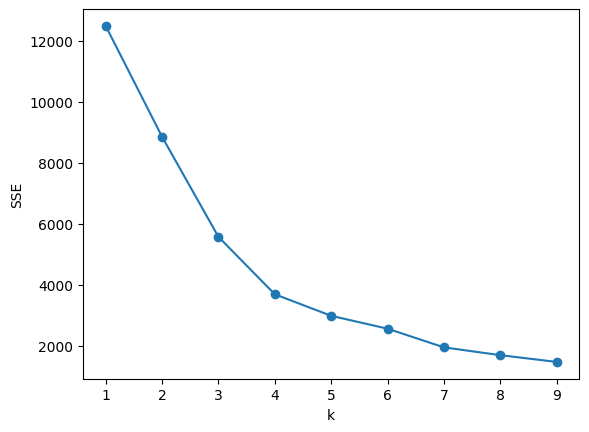

In [8]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

sse = []
for k in range(1,10):
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(rfm_scaled)
    sse.append(km.inertia_)

plt.plot(range(1,10), sse, marker='o')
plt.xlabel('k')
plt.ylabel('SSE')
plt.show()

In [9]:
best_k = 0
best_score = -1

for k in range(2, 11):  # K dari 2 sampai 10
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(rfm_scaled)
    score = silhouette_score(rfm_scaled, labels)
    print(f"K={k}, Silhouette={score:.4f}")

    if score > best_score:
        best_k = k
        best_score = score

print("\nK terbaik =", best_k)
print("Silhouette terbaik =", best_score)

K=2, Silhouette=0.5152
K=3, Silhouette=0.5299
K=4, Silhouette=0.5775
K=5, Silhouette=0.5102
K=6, Silhouette=0.4767
K=7, Silhouette=0.4736
K=8, Silhouette=0.4741
K=9, Silhouette=0.4510
K=10, Silhouette=0.3866

K terbaik = 4
Silhouette terbaik = 0.5774654704861916


In [10]:
kmeans = KMeans(n_clusters=best_k, random_state=42)
rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

In [11]:
print("\nDistribusi Cluster:")
print(rfm['Cluster'].value_counts())


Distribusi Cluster:
Cluster
0    2856
1    1051
3     255
2       3
Name: count, dtype: int64


In [12]:
# Simpan model
joblib.dump(kmeans, 'kmeans_model.pkl')

print("Model disimpan sebagai 'kmeans_model.pkl'")

Model disimpan sebagai 'kmeans_model.pkl'


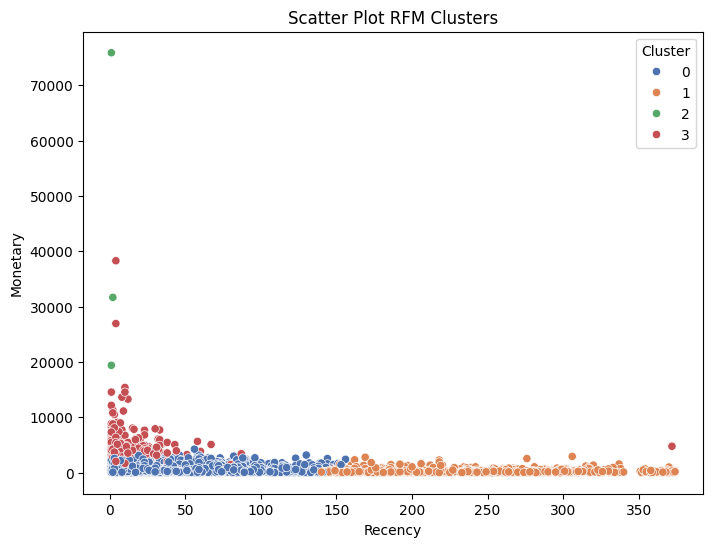

In [13]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=rfm, x='Recency', y='Monetary', hue='Cluster', palette='deep')
plt.title('Scatter Plot RFM Clusters')
plt.show()

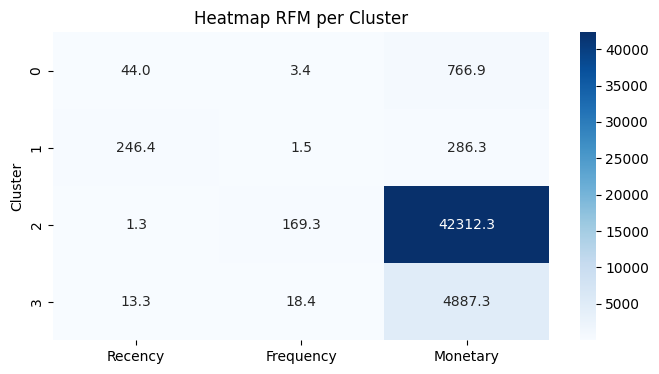

In [14]:
rfm_cluster_mean = rfm.groupby('Cluster').mean()

plt.figure(figsize=(8,4))
sns.heatmap(rfm_cluster_mean, annot=True, fmt=".1f", cmap="Blues")
plt.title("Heatmap RFM per Cluster")
plt.show()

In [16]:
import plotly.express as px

fig = px.scatter_3d(
    rfm,
    x='Recency',
    y='Frequency',
    z='Monetary',
    color='Cluster',
    title="3D Interactive RFM Clustering",
    opacity=0.8,
    size='Monetary',
    hover_data=['Recency', 'Frequency', 'Monetary']
)

fig.show()


In [15]:
# Memberikan nama atau kategori ke masing-masing cluster
import numpy as np

def segment_cluster(row):
    if row['Recency'] <= rfm['Recency'].quantile(0.25) and \
       row['Frequency'] >= rfm['Frequency'].quantile(0.75) and \
       row['Monetary'] >= rfm['Monetary'].quantile(0.75):
        return 'VIP'

    elif row['Frequency'] >= rfm['Frequency'].quantile(0.60):
        return 'Loyal'

    elif row['Recency'] >= rfm['Recency'].quantile(0.75) and \
         row['Frequency'] >= rfm['Frequency'].quantile(0.40):
        return 'At-Risk'

    elif row['Recency'] >= rfm['Recency'].quantile(0.90):
        return 'Lost'

    else:
        return 'Low-Value'

rfm['Segment'] = rfm.apply(segment_cluster, axis=1)
rfm.head()


,Recency,Frequency,Monetary,Cluster,Segment
CustomerID,,,,,
12347.0,2,7,2866.77,0,VIP
12348.0,249,1,17.00,1,Low-Value
12349.0,19,1,1155.75,0,Low-Value
12350.0,310,1,274.00,1,Lost
12352.0,36,7,1147.44,0,Loyal


# Kesimpulan :
Analisis segmentasi pelanggan menggunakan metode RFM (Recency, Frequency, Monetary) dan algoritma K-Means menghasilkan beberapa kelompok pelanggan yang memiliki karakteristik perilaku belanja berbeda. Interpretasi tiap segmen adalah sebagai berikut:

---

1.   Segmen VIP - Segmen ini berisi pelanggan dengan frekuensi pembelian tinggi, nilai transaksi besar, dan baru saja melakukan transaksi.

Ciri-ciri :
- Recency rendah (baru belanja)
- Frequency tinggi
- Monetary sangat tinggi

Interpretasi:
Pelanggan ini merupakan kontributor pendapatan terbesar dan memiliki nilai strategis yang tinggi. Perusahaan harus memprioritaskan program eksklusif seperti loyalty premium, early access, atau
personalisasi penawaran.

---

2.   Segmen Loyal - Segmen ini terdiri dari pelanggan yang membeli cukup sering dan memiliki nilai transaksi stabil.

Ciri-ciri:
- Frequency di atas rata-rata
- Monetary menengah
- Recency cukup baik

Interpretasi:
Pelanggan ini sudah memiliki engagement yang kuat dan berpotensi menjadi VIP jika diberikan insentif tambahan. Program cocok: poin reward, diskon rutin, membership.

---

3.   Segmen At-Risk - Segmen ini menunjukkan pelanggan yang sebelumnya aktif tetapi belakangan mulai jarang berbelanja.

Ciri-ciri:
- Recency tinggi
- Frequency masih cukup tinggi
- Monetary pernah besar

Interpretasi:
Pelanggan ini berisiko pindah ke kompetitor. Perlu strategi retensi seperti email reminder, voucher comeback, atau campaign re-engagement.

---

4.    Segmen Lost - Pelanggan yang sudah sangat lama tidak melakukan transaksi.

Ciri-ciri:

- Recency sangat tinggi
- Frequency rendah
- Monetary rendah

Interpretasi:
Segmen ini memiliki potensi rendah untuk kembali. Bisa diberi promosi agresif, tetapi tidak menjadi prioritas utama.

---

5.    Segmen Low-Value - Pelanggan dengan aktivitas dan nilai pembelian rendah.

Ciri-ciri:
- Frequency rendah
- Monetary kecil
- Recency bervariasi

Interpretasi:
Pelanggan ini biasanya baru pertama kali belanja atau hanya pembeli insidental. Perlu edukasi produk dan campaign akuisisi ringan.